In [ ]:
import numpy as np
import pandas as pd
from math import *
import itertools

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import csv
import matplotlib.pyplot as plt
import seaborn as sns

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# calibration
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

# metrics

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import brier_score_loss

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error    
                            
import tensorflow as tf
from tensorflow import keras

import os
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
import visualkeras


from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization,BatchNormalization
#CNN

#utils
from tensorflow.keras.utils import to_categorical

#callbacks
from tensorflow.keras.callbacks import EarlyStopping


In [160]:

early_stop_val_loss = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
early_stop_val_acu = EarlyStopping(
    monitor='val_Accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True
)

In [161]:
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

In [ ]:
#path = os.path.join(os.getcwd(), 'smart_grid_stability_augmented_dataset','smart_grid_stability_augmented.csv')
path = '/kaggle/input/datasets/smartgrids/smart-grid-stability/smart_grid_stability_augmented.csv'
df = pd.read_csv(path)
print(df.columns.values)

['tau1' 'tau2' 'tau3' 'tau4' 'p1' 'p2' 'p3' 'p4' 'g1' 'g2' 'g3' 'g4'
 'stab' 'stabf']


In [163]:
print(df.info())
print(df.isnull().sum() == 0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    60000 non-null  float64
 1   tau2    60000 non-null  float64
 2   tau3    60000 non-null  float64
 3   tau4    60000 non-null  float64
 4   p1      60000 non-null  float64
 5   p2      60000 non-null  float64
 6   p3      60000 non-null  float64
 7   p4      60000 non-null  float64
 8   g1      60000 non-null  float64
 9   g2      60000 non-null  float64
 10  g3      60000 non-null  float64
 11  g4      60000 non-null  float64
 12  stab    60000 non-null  float64
 13  stabf   60000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 6.4+ MB
None
tau1     True
tau2     True
tau3     True
tau4     True
p1       True
p2       True
p3       True
p4       True
g1       True
g2       True
g3       True
g4       True
stab     True
stabf    True
dtype: bool


In [164]:
# Encode target variable (stable=1, unstable=0)
df['stabf'] = df['stabf'].map({'stable': 1, 'unstable': 0})
# Separate predictors and target
X = df.drop(columns=['stabf'])
y = df['stabf']
# Convert back to DataFrame for readability
X = pd.DataFrame(X, columns=X.columns)
dfModelParam = pd.DataFrame({})

In [165]:
X.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,5.250000,5.250001,5.250001,5.250001,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742434,2.742437,2.742437,2.742437,0.752129,0.433017,0.433017,0.433017,0.274244,0.274243,0.274243,0.274243,0.036917
min,0.500793,0.500141,0.500141,0.500141,1.582590,-1.999945,-1.999945,-1.999945,0.050009,0.050028,0.050028,0.050028,-0.080760
25%,2.874892,2.875011,2.875011,2.875011,3.218300,-1.624997,-1.624997,-1.624997,0.287521,0.287497,0.287497,0.287497,-0.015557
50%,5.250004,5.249981,5.249981,5.249981,3.751025,-1.249996,-1.249996,-1.249996,0.525009,0.525007,0.525007,0.525007,0.017142
75%,7.624690,7.624896,7.624896,7.624896,4.282420,-0.874993,-0.874993,-0.874993,0.762435,0.762490,0.762490,0.762490,0.044878
max,9.999469,9.999837,9.999837,9.999837,5.864418,-0.500025,-0.500025,-0.500025,0.999937,0.999982,0.999982,0.999982,0.109403


In [166]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Step 6: Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_one_hot = to_categorical(y_train, 2)
y_test_one_hot  = to_categorical(y_test,  2)
y_test_one_hot[0:5,:]

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

#### Create sequential Models based on neural network


In [167]:
df.shape,X_train_scaled.shape,y_train.shape

((60000, 14), (48000, 13), (48000,))

In [168]:
#clear the session to reset the name counters
tf.compat.v1.reset_default_graph()
tf.random.set_seed(42)
# Build Neural Network
tableDispFormatt('Build Neural Network')
nn_relu_softmax_xav = Sequential()
nn_relu_softmax_xav.add(keras.layers.InputLayer(shape = (X_train_scaled.shape[1],)))
nn_relu_softmax_xav.add(keras.layers.Flatten())
nn_relu_softmax_xav.add(keras.layers.Dense(units = 20,name = 'Layer20',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_relu_softmax_xav.add(keras.layers.Dense(units = 10,name = 'Layer10',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_relu_softmax_xav.add(keras.layers.Dense(units = 5,name = 'Layer5',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_relu_softmax_xav.add(keras.layers.Dense(units = 2,name = 'OutPut2',activation="softmax",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
# ==============================================================================================
# Models Summary
tableDispFormatt('Models Summary')
nn_relu_softmax_xav.summary()
# ==============================================================================================
tableDispFormatt('Models compile')
run_eagerly_status = True
nn_relu_softmax_xav.compile(
    optimizer    = keras.optimizers.Adam(learning_rate=0.001),
    # ================ Loss & Loss weight ==========================================
    loss         = 'CategoricalCrossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['CategoricalAccuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)
# ====================================================================================================
# Train model
tableDispFormatt('Models Train')
batch_size_  = 64
epochs_      = 30
sample_size_ = X_train_scaled.shape[0]
Validation_sample_set = X_test_scaled.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_nn_relu_softmax_xav = nn_relu_softmax_xav.fit(x = X_train_scaled, y = y_train_one_hot, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test_scaled, y_test_one_hot),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_,         
)

=============================== Build Neural Network =======================================


=============================== Models Summary =============================================


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer20 (Dense)                 │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer10 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer5 (Dense)                  │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutPut2 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557 (2.18 KB)

 Trainable params: 557 (2.18 KB)

 Non-trainable params: 0 (0.00 B)

=============================== Models compile =============================================
=============================== Models Train ===============================================
Step per epoch: 750
validation_steps: 187
Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - CategoricalAccuracy: 0.8230 - loss: 0.3295 - val_CategoricalAccuracy: 0.9810 - val_loss: 0.0452
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - CategoricalAccuracy: 0.9860 - loss: 0.0353 - val_CategoricalAccuracy: 0.9881 - val_loss: 0.0269
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - CategoricalAccuracy: 0.9916 - loss: 0.0218 - val_CategoricalAccuracy: 0.9913 - val_loss: 0.0207
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - CategoricalAccuracy: 0.9934 - loss: 0.0165 - val_CategoricalAccuracy: 0.9927 - val_loss: 0.0177
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - CategoricalAccuracy: 0.9945 - loss: 0.0137 - val_CategoricalAccuracy: 0.9931 - val_loss: 0.0154
Epoch 6/30
7

#### Learning Curves: Plot training vs validation loss/accuracy to detect overfitting or underfitting

History Columns name: Index(['CategoricalAccuracy', 'loss', 'val_CategoricalAccuracy', 'val_loss',
       'epoch'],
      dtype='object')


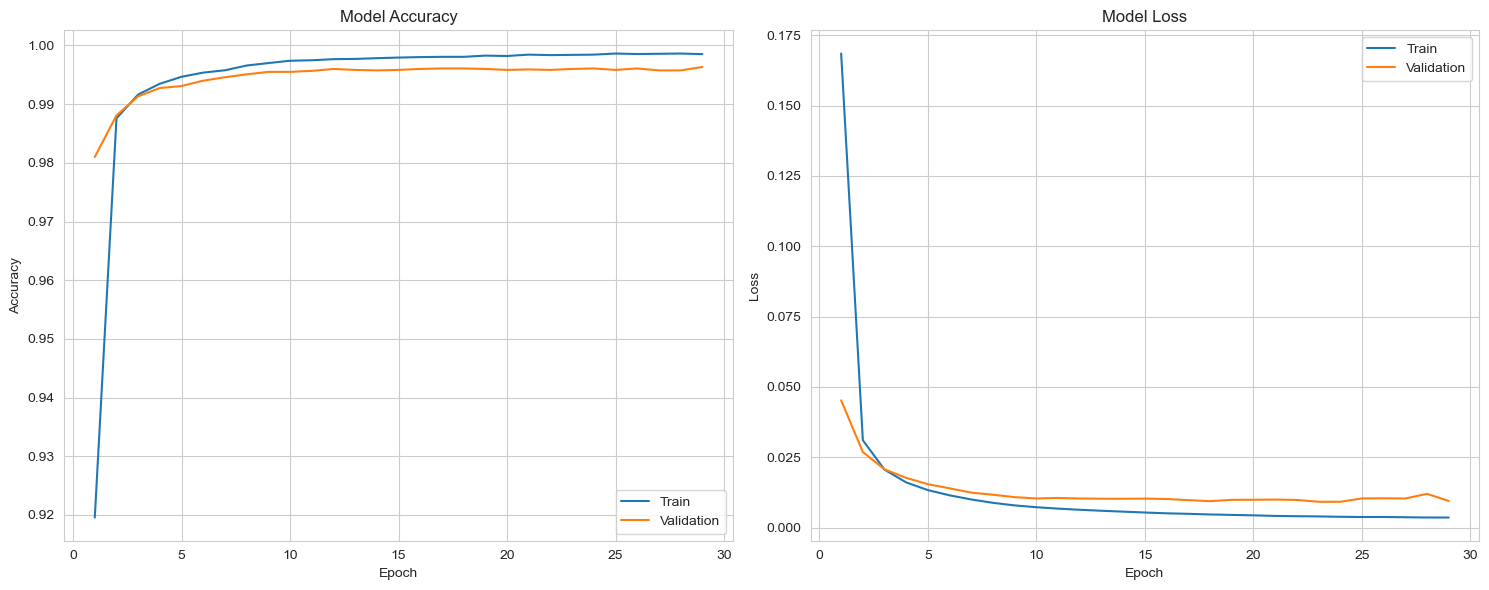

In [169]:
history_df = pd.DataFrame(history_nn_relu_softmax_xav.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Model Accuracy and Model Loss Analysis:

#### Model Accuracy
**- Blue line (Training Accuracy)**:
    - Starts lower in the first few epochs.
    - Rapidly increases as the model learns patterns.
    - Plateaus near ~0.99–1.00, showing the model fits the training data extremely well.
**- Orange line (Validation Accuracy)**:
    - Follows a similar trajectory to training accuracy.
    - Also rises quickly, then stabilizes close to training accuracy.
    - The small gap between training and validation accuracy **indicates good generalization** (no major overfitting)


#### Model Loss
**- Blue line (Training Loss):**
    - Starts relatively high (~0.175).
    - Drops steeply in the first few epochs as the model learns.
    - Gradually decreases and stabilizes near zero, showing convergence.
**- Orange line (Validation Loss):**
    - Mirrors the training loss curve.
    - Declines steadily, stabilizing close to training loss.
    - The overlap suggests the model is not overfitting — validation performance is consistent.

- Rapid Learning: The model quickly captures the underlying patterns within the first ~5–10 epochs.
- Convergence: Both accuracy and loss stabilize after ~15–20 epochs, meaning additional training doesn’t significantly improve performance.
- Strong Generalization: Training and validation curves are closely aligned, showing the model performs equally well on unseen data.
- Well-Trained Model: High accuracy (~99%) and low loss indicate excellent predictive power.


Model that learns quickly, converges smoothly, and generalizes well. Training and validation metrics track closely, confirming that the model is both accurate and reliable **without signs of overfitting**.


#### --- ROC-AUC Plot ---


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


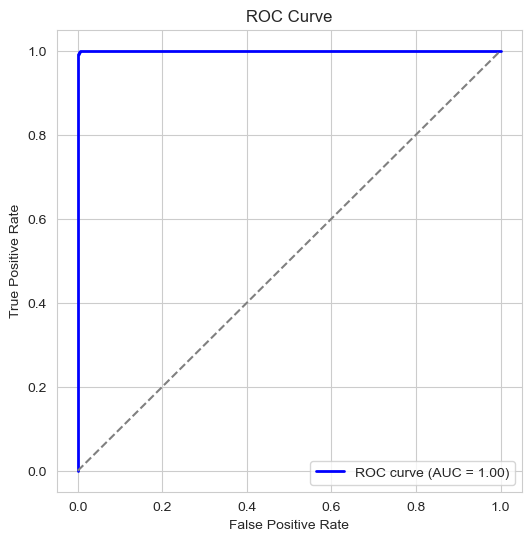

In [170]:
y_pred_proba = nn_relu_softmax_xav.predict(X_test_scaled)[:, 1]  # Use probabilities for class 1

# Convert one-hot encoded y_test_one_hot back to 1D labels
y_test_labels = y_test_one_hot.argmax(axis=1)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_labels, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

#### Get Test Accuracy & Loss

In [171]:
loss, acc = nn_relu_softmax_xav.evaluate(X_test_scaled, y_test_one_hot)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - CategoricalAccuracy: 0.9959 - loss: 0.0099
Test Loss: 0.009175285696983337
Test Accuracy: 0.9960833191871643


#### Confusion Matrix heatmap

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[[7624   32]
 [  15 4329]]


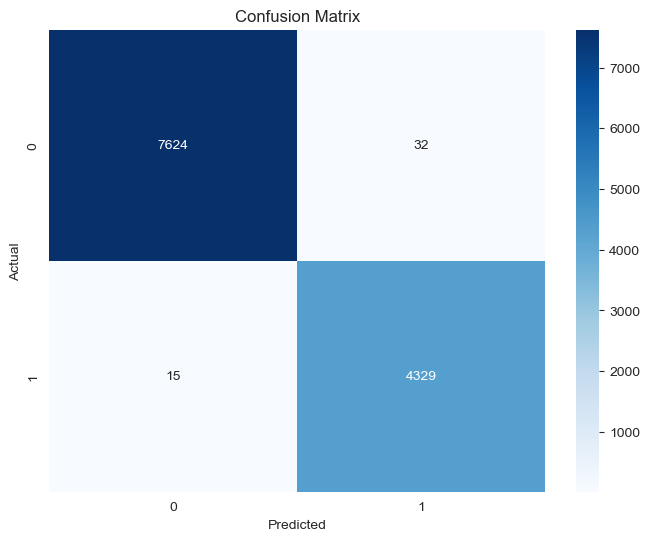

In [172]:
y_proba = nn_relu_softmax_xav.predict(X_test_scaled)
y_pred = y_proba.argmax(axis=1)
y_true = y_test_one_hot.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

- Top-left (7624):
Actual = 0, Predicted = 0 → True Negative (TN)
→ Correctly identified class 0 cases.
- Top-right (32):
Actual = 0, Predicted = 1 → False Positive (FP)
→ The model mislabeled 32 class 0 cases as class 1.
- Bottom-left (15):
Actual = 1, Predicted = 0 → False Negative (FN)
→ The model missed 15 class 1 cases, predicting them as class 0.
- Bottom-right (4329):
Actual = 1, Predicted = 1 → True Positive (TP)
→ Correctly identified class 1 cases

- Accuracy  = 99.6%  → Extremely high accuracy.
- Precision = 99.3%  → When the model predicts class 1, it’s correct ~99% of the time.
- Recall    = 99.7%  → Captures nearly all actual class 1 cases.
- Recall    = 99.6%  → Excellent detection of class 0 cases.

Confusion matrix shows a near-perfect classifier. It almost flawlessly distinguishes between the two classes, with only a handful of misclassifications. This aligns with your earlier ROC curves (AUC = 1.00), confirming the model’s outstanding discrimination ability.


##### additionals code

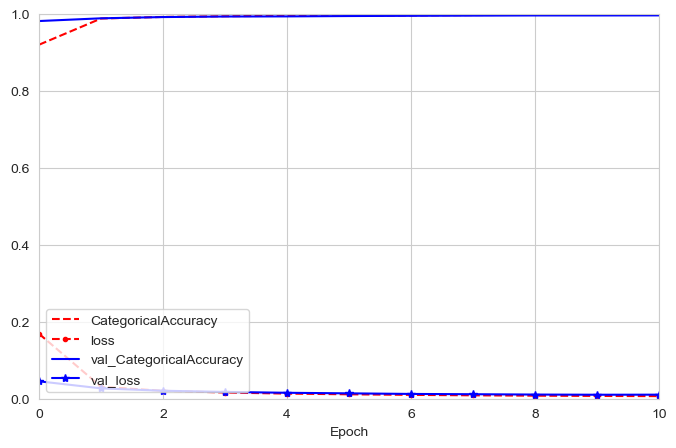

In [173]:
pd.DataFrame(history_nn_relu_softmax_xav.history).plot(
    figsize=(8, 5), xlim=[0, 10], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code

plt.show()

#### Calibration metrics:
basically checking whether the predicted probabilities from Keras neural network actually reflect the true likelihood of events.

#### Calibration Metrics Method :
- Reliability Diagram (Calibration Curve): Plots predicted probability vs. actual fraction of positives.
- Expected Calibration Error (ECE): Weighted average of the difference between predicted probability and observed frequency.
- Brier Score: Measures the mean squared error between predicted probabilities and actual outcomes.


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


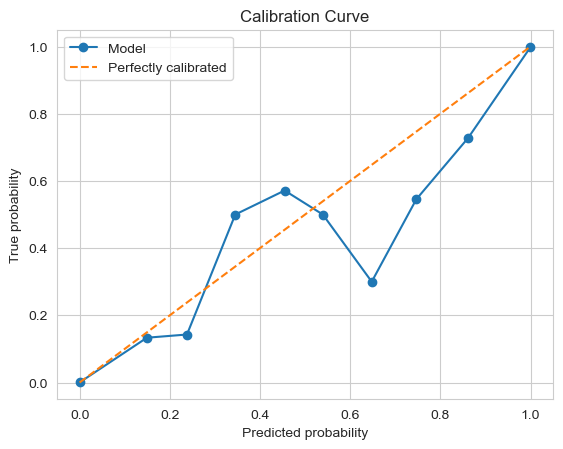

Brier score: 0.0027890283544267157


In [174]:
# Get predicted probabilities for class 1
y_pred_proba = nn_relu_softmax_xav.predict(X_test_scaled)[:, 1]

# Convert one-hot encoded y_test_one_hot back to 1D labels
y_test_labels = y_test_one_hot.argmax(axis=1)

# --- Calibration Curve ---
prob_true, prob_pred = calibration_curve(y_test_labels, y_pred_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# --- Brier Score ---
brier = brier_score_loss(y_test_labels, y_pred_proba)
print("Brier score:", brier)



- "Perfectly calibrated" (orange dashed line)
- "Model" (blue solid line)

Interpretation of the Model's Performance
**- Below the diagonal (Overconfidence)**: In the predicted probability range of approximately 0.1 to 0.4, the model line is below the ideal line. This means the model is overconfident in its low predictions; when it predicts an event has a 30% chance, the event actually happens less than 30% of the time.

**- Above the diagonal (Underconfidence):** In the range of approximately 0.5 to 0.8, the model line is above the ideal line. This indicates the model is underconfident in its higher predictions; when it predicts an event has a 70% chance, it actually occurs more often than 70% of the time.

**- Near the ends (Well-calibrated):** At probabilities near 0.0 and 1.0, the model is well-calibrated as the points lie directly on the diagonal

Brier Score Explained
- Range: The score ranges from 0 to 1.
- Ideal Value: A Brier score of 0 indicates a perfectly calibrated and accurate model, meaning the predicted probabilities exactly match the actual outcomes.
- Interpretation: The lower the score, the better the model's performance. A score of 1 represents the worst possible prediction

For the calibration curve shown, a Brier score of 0.0027890283544267157 is an extremely low value, indicating that the model's predictions are highly accurate and very well-calibrated overall.

#### Expected Calibration Error (ECE)

Not sure result is corrected. I need to varify

In [175]:
y_pred_proba = nn_relu_softmax_xav.predict(X_test_scaled).ravel()
# Ensure y_test is a NumPy array and has the same length as y_pred_proba
y_test_array = y_test.to_numpy() if isinstance(y_test, pd.Series) else np.array(y_test)

# Adjust lengths if there is a mismatch
min_length = min(len(y_test_array), len(y_pred_proba))
y_test_array = y_test_array[:min_length]
y_pred_proba = y_pred_proba[:min_length]

# Function to compute ECE
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    n = len(y_true)
    
    for i in range(n_bins):
        # Indices of samples in bin
        idx = np.where((y_prob >= bins[i]) & (y_prob < bins[i+1]))[0]
        if len(idx) == 0:
            continue
        
        # Ensure indices are within bounds
        idx = idx[idx < len(y_true)]
        
        # Accuracy in bin
        acc = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
        # Confidence in bin
        conf = np.mean(y_prob[idx])
        
        # Weighted difference
        ece += (len(idx) / n) * abs(acc - conf)
    
    return ece

ece_value = expected_calibration_error(y_test_array, y_pred_proba, n_bins=10)
print("Expected Calibration Error (ECE):", ece_value)


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Expected Calibration Error (ECE): 0.34867780637638496


**Expected Calibration Error (ECE)** quantifies the difference between a model's predicted probabilities and the actual outcomes. The ideal ECE value is 0, which represents a perfectly calibrated model & model's predicted probabilities exactly match the true observed probabilities.

An Expected Calibration Error (ECE) of 0.3486 is considered a high value in machine learning, indicating that the model is poorly calibrated.

#### Brier score Vs ECE:

The Brier score is a comprehensive metric (a proper scoring rule) that is influenced by:
- **Uncertainty**: The inherent randomness in the outcomes.
- **Resolution** (Sharpness/Discrimination): The model's ability to make varying, confident predictions (distinguishing positive from negative cases).
- **Reliability** (Calibration): How well the predicted probabilities match the observed frequencies.

The ECE focuses only on the reliability (calibration) component.

**Low Brier Score (0.0027)**: This indicates **excellent overall performance**. The model is likely very good at discriminating between classes and makes predictions that are, on average, very close to the actual outcomes.

**High ECE (0.3486)**: This indicates poor calibration, specifically a systematic bias in the model's confidence levels. The model might consistently predict very high or very low probabilities (e.g., always 0% or 100%) which align well with the true outcomes in an overall mean-squared-error sense, but the actual confidence scores might be misleading when grouped into bins.

The model might be highly accurate in its final prediction outcomes, but its stated confidence scores (the probabilities themselves) are not trustworthy. The ECE flags this specific issue, while the Brier score, due to its mathematical formulation and dependence on other factors like class imbalance, gives a deceptively positive overall picture.

In [176]:
#clear the session to reset the name counters
tf.compat.v1.reset_default_graph()
tf.random.set_seed(42)
# Build Neural Network
tableDispFormatt('Build Neural Network')
malpha = 0.2
nn_leaky_relu_softmax_he_uni = Sequential()
nn_leaky_relu_softmax_he_uni.add(keras.layers.InputLayer(shape = (X_train_scaled.shape[1],)))
nn_leaky_relu_softmax_he_uni.add(keras.layers.Flatten())
nn_leaky_relu_softmax_he_uni.add(keras.layers.Dense(units = 20,name = 'Layer20',
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_leaky_relu_softmax_he_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
nn_leaky_relu_softmax_he_uni.add(keras.layers.Dense(units = 10,name = 'Layer10',
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_leaky_relu_softmax_he_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
nn_leaky_relu_softmax_he_uni.add(keras.layers.Dense(units = 5,name = 'Layer5',
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_leaky_relu_softmax_he_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
nn_leaky_relu_softmax_he_uni.add(keras.layers.Dense(units = 2,name = 'OutPut2',activation="softmax",
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))

# ==============================================================================================
# Models Summary
tableDispFormatt('Models Summary')
nn_leaky_relu_softmax_he_uni.summary()
# ==============================================================================================
tableDispFormatt('Models compile')
run_eagerly_status = True
nn_leaky_relu_softmax_he_uni.compile(
    optimizer    = keras.optimizers.Adam(learning_rate=0.001),
    # ================ Loss & Loss weight ==========================================
    loss         = 'CategoricalCrossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['CategoricalAccuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)
# ==============================================================================================
# Train model
tableDispFormatt('Models Train')
batch_size_  = 64
epochs_      = 30
sample_size_ = X_train_scaled.shape[0]
Validation_sample_set = X_test_scaled.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_nn_leaky_relu_softmax_he_uni = nn_leaky_relu_softmax_he_uni.fit(x = X_train_scaled, y = y_train_one_hot, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test_scaled, y_test_one_hot),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_,         
)


=============================== Build Neural Network =======================================
=============================== Models Summary =============================================


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer20 (Dense)                 │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer10 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer5 (Dense)                  │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutPut2 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557 (2.18 KB)

 Trainable params: 557 (2.18 KB)

 Non-trainable params: 0 (0.00 B)

=============================== Models compile =============================================
=============================== Models Train ===============================================
Step per epoch: 750
validation_steps: 187
Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - CategoricalAccuracy: 0.8159 - loss: 0.3624 - val_CategoricalAccuracy: 0.9744 - val_loss: 0.0589
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - CategoricalAccuracy: 0.9814 - loss: 0.0463 - val_CategoricalAccuracy: 0.9841 - val_loss: 0.0351
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - CategoricalAccuracy: 0.9893 - loss: 0.0273 - val_CategoricalAccuracy: 0.9868 - val_loss: 0.0275
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - CategoricalAccuracy: 0.9922 - loss: 0.0202 - val_CategoricalAccuracy: 0.9886 - val_loss: 0.0233
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - CategoricalAccuracy: 0.9936 - loss: 0.0164 - val_CategoricalAccuracy: 0.9909 - val_loss: 0.0200
Epoch 6/30
7

#### Learning Curves: Plot training vs validation loss/accuracy to detect overfitting or underfitting


History Columns name: Index(['CategoricalAccuracy', 'loss', 'val_CategoricalAccuracy', 'val_loss',
       'epoch'],
      dtype='object')


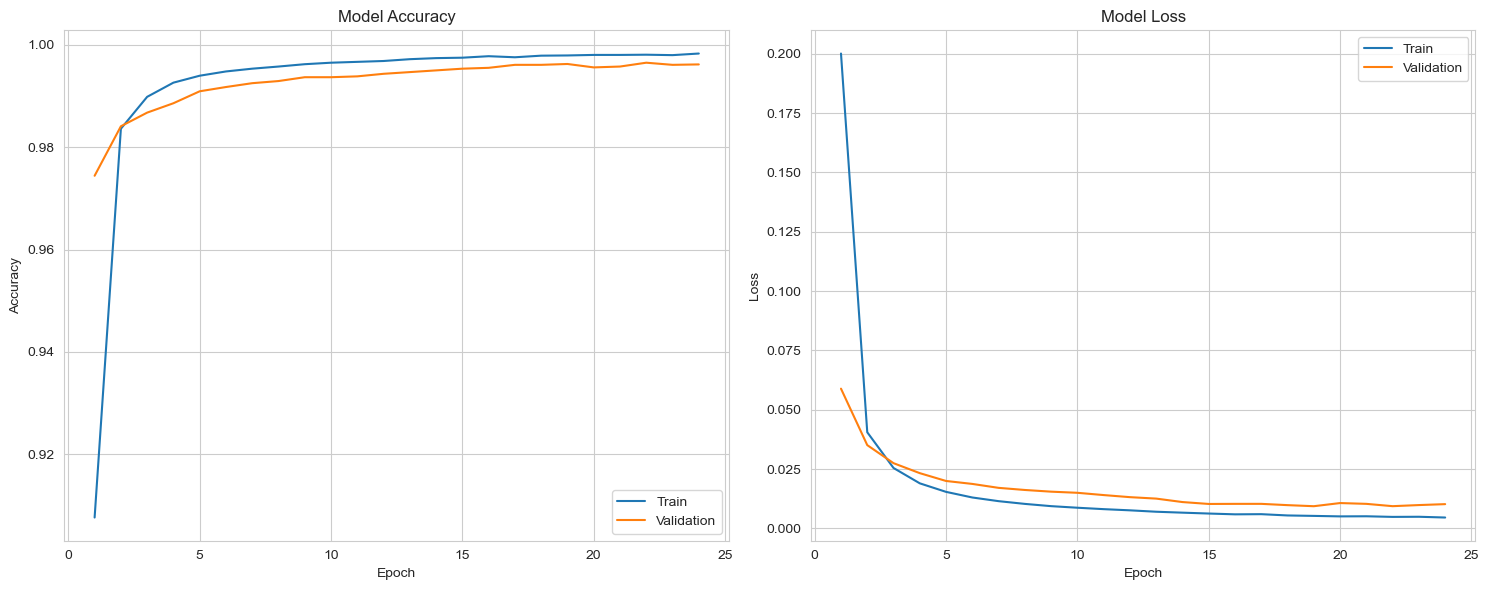

In [177]:
history_df = pd.DataFrame(history_nn_leaky_relu_softmax_he_uni.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

- Blue line (Training Accuracy):
    - Plateaus near ~0.99, showing the model fits the training data extremely well
- Orange line (Validation Accuracy):
    - The small gap between training and validation accuracy indicates good generalization (no major overfitting)

model that learns quickly, converges smoothly, and generalizes well. Training and validation metrics track closely, confirming that the model is both accurate and reliable without signs of overfitting.

Would you like me to also connect these curves back to your calibration plots so you can see how epoch‑by‑epoch training affects not just accuracy/loss, but also the reliability of predicted probabilities?



#### --- ROC-AUC Plot ---

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


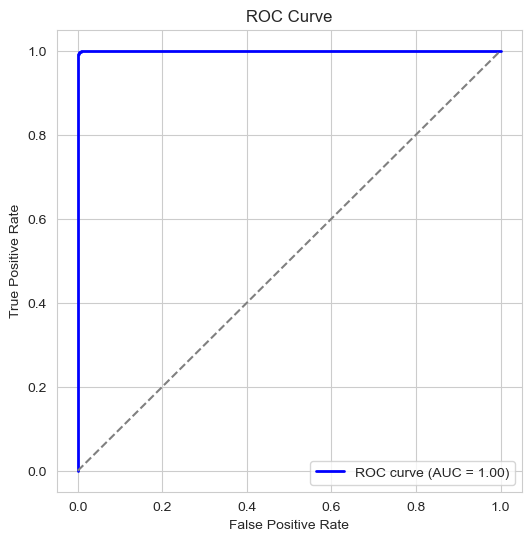

In [178]:
#### --- ROC-AUC Plot ---
y_pred_proba = nn_leaky_relu_softmax_he_uni.predict(X_test_scaled)[:, 1]  # Use probabilities for class 1

# Convert one-hot encoded y_test_one_hot back to 1D labels
y_test_labels = y_test_one_hot.argmax(axis=1)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_labels, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

#### Evaluate Loss and accureacy

In [179]:
loss, acc = nn_leaky_relu_softmax_he_uni.evaluate(X_test_scaled, y_test_one_hot)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - CategoricalAccuracy: 0.9952 - loss: 0.0100
Test Loss: 0.00934363529086113
Test Accuracy: 0.9962499737739563


#### Confusion Matrix Plot

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
[[7630   26]
 [  19 4325]]


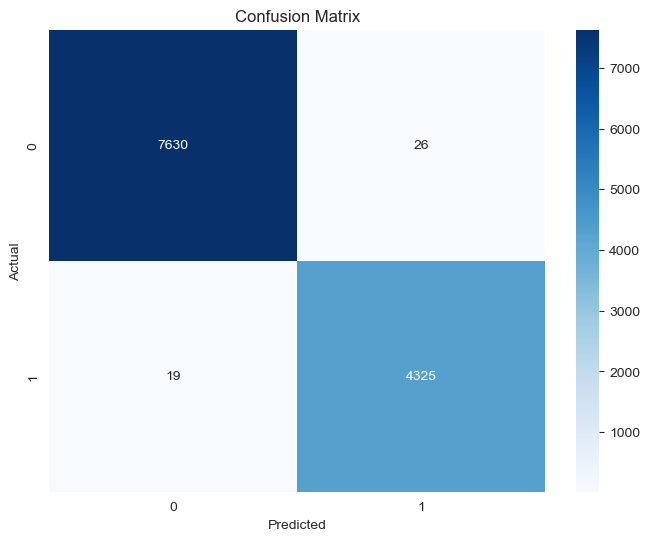

In [180]:
y_proba = nn_leaky_relu_softmax_he_uni.predict(X_test_scaled)
y_pred = y_proba.argmax(axis=1)
y_true = y_test_one_hot.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

confusion matrix shows a near-perfect classifier. It almost flawlessly distinguishes between the two classes, with only a handful of misclassifications.

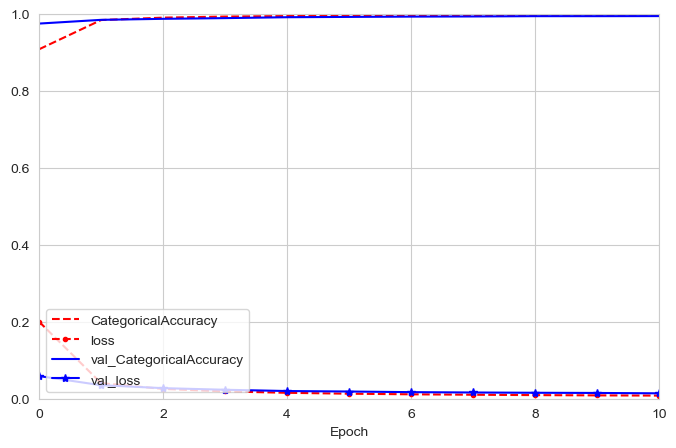

In [181]:
pd.DataFrame(history_nn_leaky_relu_softmax_he_uni.history).plot(
    figsize=(8, 5), xlim=[0, 10], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code

plt.show()

#### Evaluate Calibration Curve and Brier Score


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


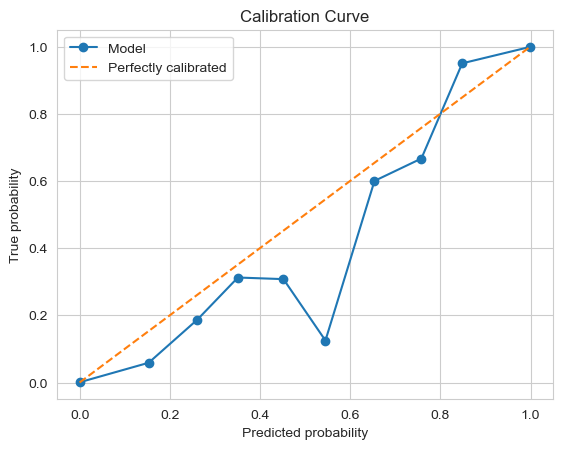

Brier score: 0.002710964261503511


In [182]:
# Get predicted probabilities for class 1
y_pred_proba = nn_leaky_relu_softmax_he_uni.predict(X_test_scaled)[:, 1]

# Convert one-hot encoded y_test_one_hot back to 1D labels
y_test_labels = y_test_one_hot.argmax(axis=1)

# --- Calibration Curve ---
prob_true, prob_pred = calibration_curve(y_test_labels, y_pred_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# --- Brier Score ---
brier = brier_score_loss(y_test_labels, y_pred_proba)
print("Brier score:", brier)

#### Expected Calibration Error (ECE) 


In [183]:
y_pred_proba = nn_leaky_relu_softmax_he_uni.predict(X_test_scaled).ravel()
# Ensure y_test is a NumPy array and has the same length as y_pred_proba
y_test_array = y_test.to_numpy() if isinstance(y_test, pd.Series) else np.array(y_test)

# Adjust lengths if there is a mismatch
min_length = min(len(y_test_array), len(y_pred_proba))
y_test_array = y_test_array[:min_length]
y_pred_proba = y_pred_proba[:min_length]

# Function to compute ECE
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    n = len(y_true)
    
    for i in range(n_bins):
        # Indices of samples in bin
        idx = np.where((y_prob >= bins[i]) & (y_prob < bins[i+1]))[0]
        if len(idx) == 0:
            continue
        
        # Ensure indices are within bounds
        idx = idx[idx < len(y_true)]
        
        # Accuracy in bin
        acc = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
        # Confidence in bin
        conf = np.mean(y_prob[idx])
        
        # Weighted difference
        ece += (len(idx) / n) * abs(acc - conf)
    
    return ece

ece_value = expected_calibration_error(y_test_array, y_pred_proba, n_bins=10)
print("Expected Calibration Error (ECE):", ece_value)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Expected Calibration Error (ECE): 0.347467251034992


Brier score and Expected Calibration Error (ECE) both explained in previous models.
For this models both are not much different.

In [184]:
#clear the session to reset the name counters
tf.compat.v1.reset_default_graph()
tf.random.set_seed(42)
# Build Neural Network
tableDispFormatt('Build Neural Network')
malpha = 0.2
nn_leaky_relu_sigmoid_normz_dropout_xav_uni = Sequential()
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.InputLayer(shape = (X_train_scaled.shape[1],)))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.Flatten())
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.Dense(units = 20,name = 'Layer20',
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(BatchNormalization())
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(Dropout(0.3))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.Dense(units = 10,name = 'Layer10',
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(BatchNormalization())
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(Dropout(0.3))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.Dense(units = 5,name = 'Layer5',
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(BatchNormalization())
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(Dropout(0.3))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.Dense(units = 2,name = 'Layer2',
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(BatchNormalization())
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(Dropout(0.3))
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.add(keras.layers.Dense(units = 1,name = 'OutPut1',activation="sigmoid",
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))

# ==============================================================================================
# Models Summary
tableDispFormatt('Models Summary')
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.summary()
# ==============================================================================================
tableDispFormatt('Models compile')
run_eagerly_status = True
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.compile(
    optimizer    = keras.optimizers.Adam(learning_rate=0.001),
    # ================ Loss & Loss weight ==========================================
    loss         = 'binary_crossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['CategoricalAccuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)
# ==============================================================================================
# Train model
tableDispFormatt('Models Train')
batch_size_  = 64
epochs_      = 5
sample_size_ = X_train_scaled.shape[0]
Validation_sample_set = X_test_scaled.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_nn_leaky_relu_sigmoid_normz_dropout_xav_uni =\
nn_leaky_relu_sigmoid_normz_dropout_xav_uni.fit(x = X_train_scaled, y = y_train, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test_scaled, y_test),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_,         
)

=============================== Build Neural Network =======================================
=============================== Models Summary =============================================


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer20 (Dense)                 │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer10 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer5 (Dense)                  │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer2 (Dense)                  │ (None, 2)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutPut1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 708 (2.77 KB)

 Trainable params: 634 (2.48 KB)

 Non-trainable params: 74 (296.00 B)

=============================== Models compile =============================================
=============================== Models Train ===============================================
Step per epoch: 750
validation_steps: 187
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 66s 88ms/step - CategoricalAccuracy: 1.0000 - loss: 0.6213 - val_CategoricalAccuracy: 1.0000 - val_loss: 0.1772
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 63s 84ms/step - CategoricalAccuracy: 1.0000 - loss: 0.2706 - val_CategoricalAccuracy: 1.0000 - val_loss: 0.0494
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 65s 86ms/step - CategoricalAccuracy: 1.0000 - loss: 0.1650 - val_CategoricalAccuracy: 1.0000 - val_loss: 0.0247
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 63s 85ms/step - CategoricalAccuracy: 1.0000 - loss: 0.1381 - val_CategoricalAccuracy: 1.0000 - val_loss: 0.0211
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 66s 87ms/step - CategoricalAccuracy: 1.0000 - loss: 0.1292 - val_CategoricalAccuracy: 1.0000 - val_loss: 0.0179


In [185]:
#clear the session to reset the name counters
tf.keras.backend.clear_session()
tf.random.set_seed(42)

X_train_scaled_cnn = np.expand_dims(X_train_scaled, axis=-1)
X_test_scaled_cnn = np.expand_dims(X_test_scaled, axis=-1)


malpha = 0.2
cnn_leaky_softmax_normz_dropout_maxpool_he_uni = keras.Sequential()
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(
    keras.layers.InputLayer(shape = (X_test_scaled_cnn.shape[1], 1))
    )
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.Conv1D(filters=32, kernel_size=7, strides=1, padding="same",
                                       use_bias=True, kernel_initializer="he_uniform", bias_initializer="zeros"))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(BatchNormalization())
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(Dropout(0.25))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.MaxPooling1D(pool_size=2))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.Conv1D(filters=64, kernel_size=3, strides=1, padding="same",
                                       use_bias=True, kernel_initializer="he_uniform", bias_initializer="zeros"))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(BatchNormalization())
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.MaxPooling1D(pool_size=2))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(Dropout(0.25))
#=====================================================
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.Flatten())
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.Dense(units = 20,name = 'Layer20',
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(BatchNormalization())
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(Dropout(0.25))
#======================================================
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.Dense(units = 10,name = 'Layer10',
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(BatchNormalization())
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(Dropout(0.25))
#======================================================
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.Dense(units = 5,name = 'Layer5',
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(BatchNormalization())
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(Dropout(0.25))
#======================================================
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.LeakyReLU(negative_slope=malpha))
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.add(keras.layers.Dense(units = 2,name = 'OutPut2',
                                                                      activation="softmax",
                                                     use_bias=True,kernel_initializer="he_uniform",
                                                     bias_initializer=initializers.Zeros()))
#=====================================================
tableDispFormatt('Cnn Models Summary')
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.summary()
# ==============================================================================================
tableDispFormatt('Models compile')
run_eagerly_status = True
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.compile(
    optimizer    = keras.optimizers.Adam(learning_rate=0.001),
    # ================ Loss & Loss weight ==========================================
    loss         = 'CategoricalCrossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['CategoricalAccuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)
# ==============================================================================================
# Train model
tableDispFormatt('Models Train')
batch_size_  = 64
epochs_      = 30
sample_size_ = X_train_scaled.shape[0]
Validation_sample_set = X_test_scaled.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_cnn_leaky_softmax_normz_dropout_maxpool_he_uni =\
cnn_leaky_softmax_normz_dropout_maxpool_he_uni.fit(x = X_train_scaled, y = y_train_one_hot, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test_scaled, y_test_one_hot),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_,         
)

=============================== Cnn Models Summary =========================================


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 13, 32)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer20 (Dense)                 │ (None, 20)             │         3,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer10 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer5 (Dense)                  │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,125 (43.46 KB)

 Trainable params: 10,863 (42.43 KB)

 Non-trainable params: 262 (1.02 KB)

=============================== Models compile =============================================
=============================== Models Train ===============================================
Step per epoch: 750
validation_steps: 187
Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 92s 122ms/step - CategoricalAccuracy: 0.7870 - loss: 0.4559 - val_CategoricalAccuracy: 0.9562 - val_loss: 0.1161
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - CategoricalAccuracy: 0.9280 - loss: 0.1930 - val_CategoricalAccuracy: 0.9812 - val_loss: 0.0516
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 120ms/step - CategoricalAccuracy: 0.9566 - loss: 0.1259 - val_CategoricalAccuracy: 0.9870 - val_loss: 0.0346
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - CategoricalAccuracy: 0.9659 - loss: 0.1005 - val_CategoricalAccuracy: 0.9896 - val_loss: 0.0289
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 95s 126ms/step - CategoricalAccuracy: 0.9721 - loss: 0.0817 - val_CategoricalAccuracy: 0.9919 - val_loss: 0.0237
Epoch 6

#### Learning Curves: Plot training vs validation loss/accuracy to detect overfitting or underfitting

History Columns name: Index(['CategoricalAccuracy', 'loss', 'val_CategoricalAccuracy', 'val_loss',
       'epoch'],
      dtype='object')


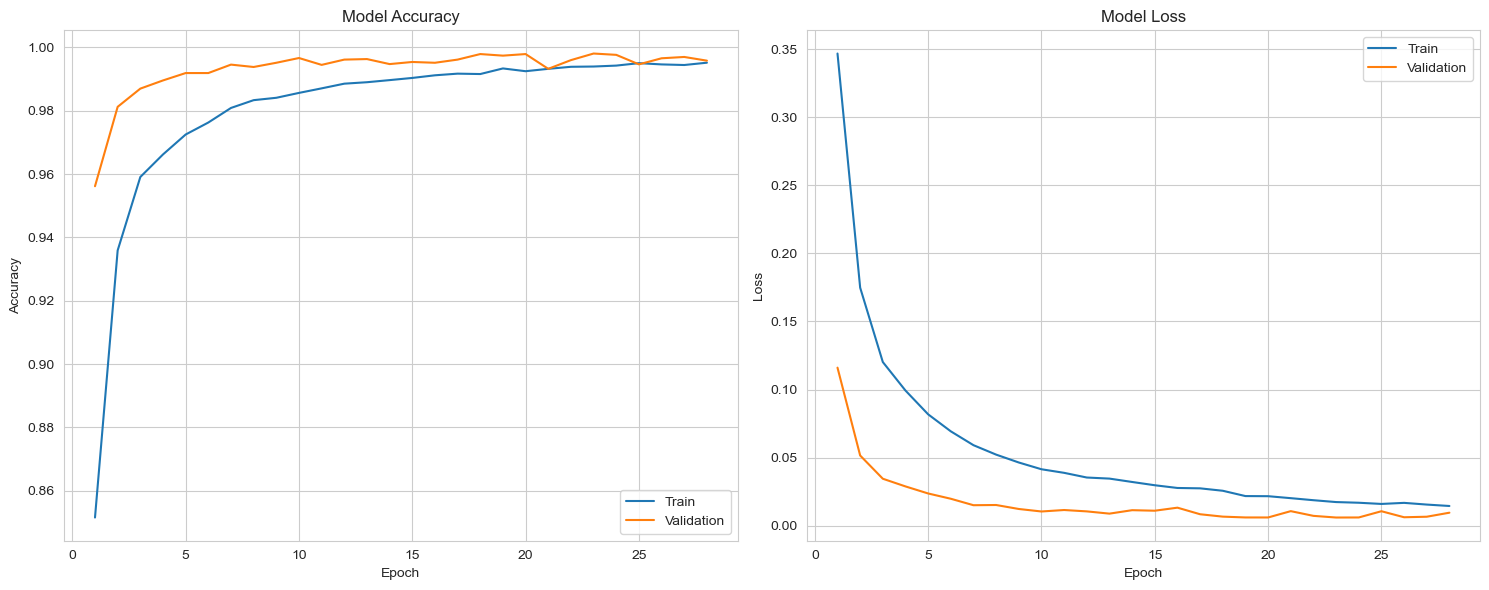

History Columns name: Index(['CategoricalAccuracy', 'loss', 'val_CategoricalAccuracy', 'val_loss',
       'epoch'],
      dtype='object')


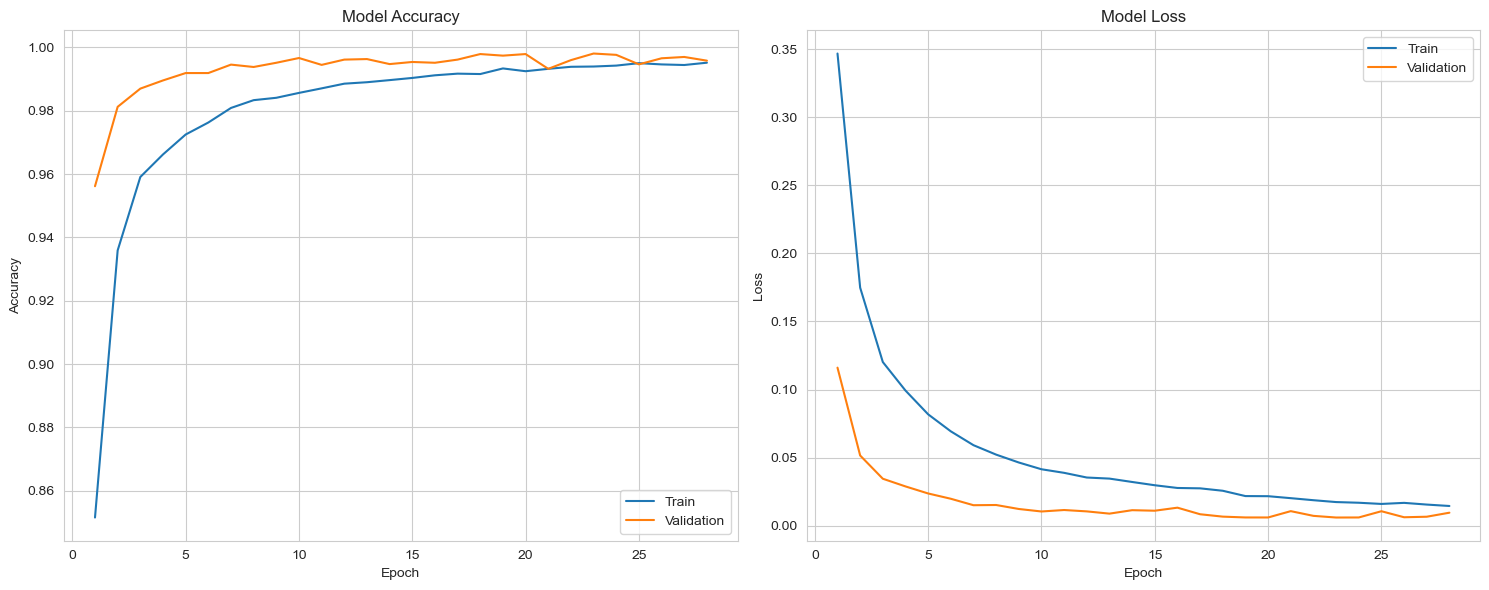

In [186]:
# Learning Curves: Plot training vs validation loss/accuracy to detect overfitting or underfitting

history_df = pd.DataFrame(history_cnn_leaky_softmax_normz_dropout_maxpool_he_uni.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

history_df = pd.DataFrame(history_cnn_leaky_softmax_normz_dropout_maxpool_he_uni.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

- Training Accuracy (blue line):
    - Plateaus near 0.99, meaning the model is learning well from the training data.
- Validation Accuracy (orange line):
    - Also rises and stabilizes near 0.99, showing the model generalizes well to unseen data.

- The model shows excellent performance: high accuracy and low loss for both training and validation.
- No overfitting or underfitting: curves are smooth, stable, and aligned


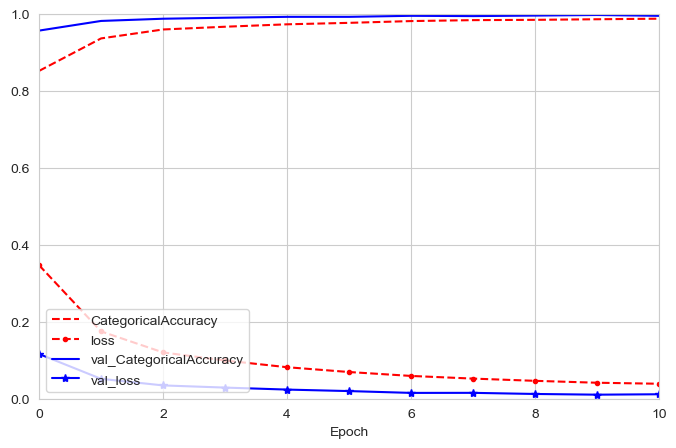

In [187]:
pd.DataFrame(history_cnn_leaky_softmax_normz_dropout_maxpool_he_uni.history).plot(
    figsize=(8, 5), xlim=[0, 10], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")  # extra code

plt.show()

#### --- ROC-AUC Plot ---

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


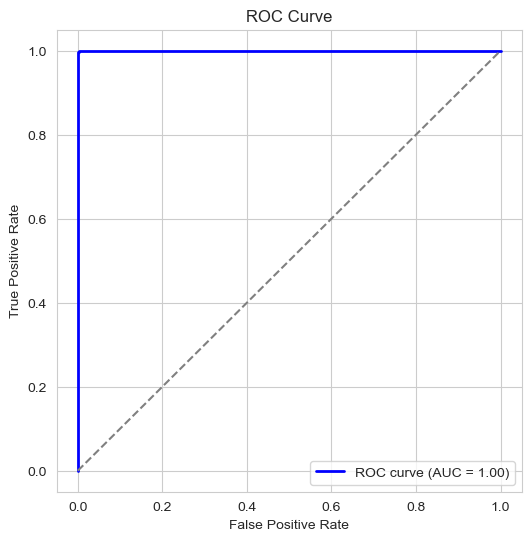

In [189]:
#### --- ROC-AUC Plot ---
y_pred_proba = cnn_leaky_softmax_normz_dropout_maxpool_he_uni.predict(X_test_scaled_cnn)[:, 1]  # Use probabilities for class 1

# Convert one-hot encoded y_test_one_hot back to 1D labels
y_test_labels = y_test_one_hot.argmax(axis=1)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_labels, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

#### Confusion Matrix Plot

#### Evaluate Loss and accureacy

In [191]:
#### Evaluate Loss and accureacy
loss, acc = cnn_leaky_softmax_normz_dropout_maxpool_he_uni.evaluate(X_test_scaled_cnn, y_test_one_hot)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - CategoricalAccuracy: 0.9977 - loss: 0.0062
Test Loss: 0.006079165730625391
Test Accuracy: 0.9980833530426025


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
[[7640   16]
 [   7 4337]]


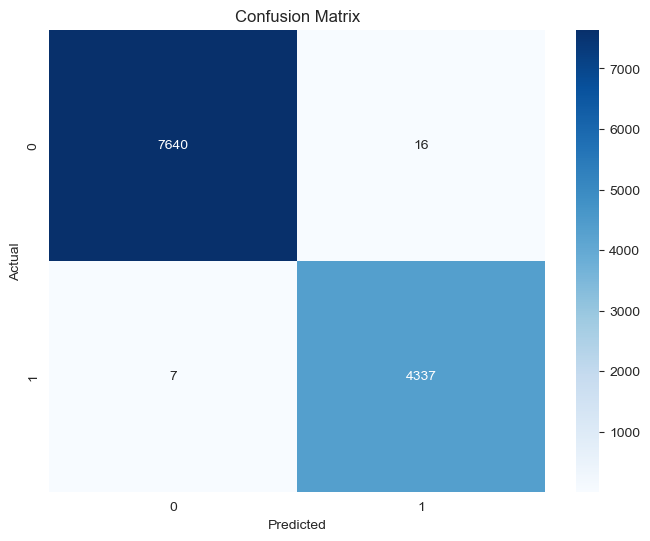

In [192]:
#### Confusion Matrix Plot
y_proba = cnn_leaky_softmax_normz_dropout_maxpool_he_uni.predict(X_test_scaled_cnn)
y_pred = y_proba.argmax(axis=1)
y_true = y_test_one_hot.argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### Evaluate Calibration Curve and Brier Score

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


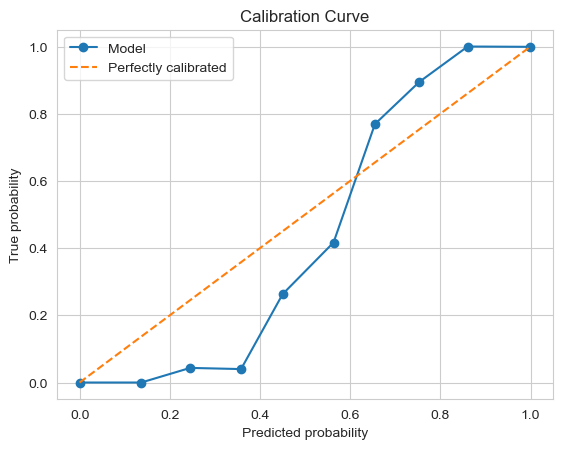

Brier score: 0.001792534615297624


In [193]:
#### Evaluate Calibration Curve and Brier Score
# Get predicted probabilities for class 1
y_pred_proba = cnn_leaky_softmax_normz_dropout_maxpool_he_uni.predict(X_test_scaled_cnn)[:, 1]

# Convert one-hot encoded y_test_one_hot back to 1D labels
y_test_labels = y_test_one_hot.argmax(axis=1)

# --- Calibration Curve ---
prob_true, prob_pred = calibration_curve(y_test_labels, y_pred_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# --- Brier Score ---
brier = brier_score_loss(y_test_labels, y_pred_proba)
print("Brier score:", brier)

#### Expected Calibration Error (ECE) 

In [194]:
#### Expected Calibration Error (ECE) 

y_pred_proba = cnn_leaky_softmax_normz_dropout_maxpool_he_uni.predict(X_test_scaled_cnn).ravel()
# Ensure y_test is a NumPy array and has the same length as y_pred_proba
y_test_array = y_test.to_numpy() if isinstance(y_test, pd.Series) else np.array(y_test)

# Adjust lengths if there is a mismatch
min_length = min(len(y_test_array), len(y_pred_proba))
y_test_array = y_test_array[:min_length]
y_pred_proba = y_pred_proba[:min_length]

# Function to compute ECE
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    n = len(y_true)
    
    for i in range(n_bins):
        # Indices of samples in bin
        idx = np.where((y_prob >= bins[i]) & (y_prob < bins[i+1]))[0]
        if len(idx) == 0:
            continue
        
        # Ensure indices are within bounds
        idx = idx[idx < len(y_true)]
        
        # Accuracy in bin
        acc = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
        # Confidence in bin
        conf = np.mean(y_prob[idx])
        
        # Weighted difference
        ece += (len(idx) / n) * abs(acc - conf)
    
    return ece

ece_value = expected_calibration_error(y_test_array, y_pred_proba, n_bins=10)
print("Expected Calibration Error (ECE):", ece_value)

375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step
Expected Calibration Error (ECE): 0.3651946568356458


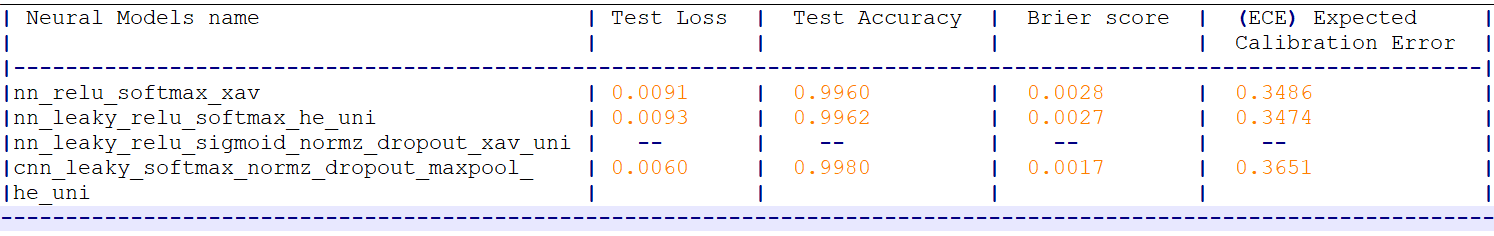

- Accuracy & Loss: The CNN model clearly outperforms the dense networks, achieving 99.8% accuracy and the lowest loss.
- Calibration (ECE): Despite its superior accuracy, the CNN has a slightly higher calibration error (~0.365 vs ~0.347). This means it’s extremely accurate but tends to be overconfident in its predictions.
- Dense Models: Both dense networks (ReLU/Leaky ReLU) are nearly as good in accuracy but slightly worse in loss. They are marginally better calibrated than the CNN.

- CNN = best raw performance.
- Dense nets = slightly better probability calibration.


- If goal is maximum accuracy, the CNN is the winner.
- If care about well-calibrated probabilities (e.g., in risk-sensitive applications), the dense models may be preferable.

#### how to apply calibration methods (like temperature scaling) to that CNN, improve its ECE without sacrificing accuracy?

TODO